<a href="https://colab.research.google.com/github/kxrrym03/Porsche-Stock-Data/blob/main/Porsche_Stock_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving porsche_stock_data.csv to porsche_stock_data.csv


In [3]:
df = pd.read_csv('porsche_stock_data.csv')
df.shape

(866, 6)

In [4]:
df.head()

,date,open,high,low,close,volume
0,2022-09-30,75.617410,76.164700,75.252548,75.252548,5079137
1,2022-10-03,75.252548,75.453222,73.884320,74.614044,2403446
2,2022-10-04,75.434974,79.795067,74.796470,79.795067,1599630
3,2022-10-05,79.448447,81.765314,78.919397,80.196411,1321304
4,2022-10-06,81.820036,85.468644,81.491661,82.750435,2217065


In [5]:
df.tail()

,date,open,high,low,close,volume
861,2026-02-19,42.000000,42.400002,41.130001,41.700001,402139
862,2026-02-20,41.400002,43.049999,41.400002,42.340000,893498
863,2026-02-23,42.169998,42.360001,40.959999,41.169998,761838
864,2026-02-24,41.200001,42.230000,41.180000,41.549999,712492
865,2026-02-25,41.490002,41.849998,41.029999,41.320000,411145


In [6]:
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    866 non-null    object 
 1   open    866 non-null    float64
 2   high    866 non-null    float64
 3   low     866 non-null    float64
 4   close   866 non-null    float64
 5   volume  866 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 40.7+ KB


In [9]:
df.describe()

,open,high,low,close,volume
count,866.000000,866.000000,866.000000,866.000000,8.660000e+02
mean,70.638938,71.434490,69.723691,70.532747,5.674776e+05
std,21.944210,22.131165,21.628439,21.899780,5.673197e+05
min,39.120645,40.029999,38.398831,39.529999,0.000000e+00
25%,46.747500,47.462501,46.304999,46.809999,3.100342e+05
50%,69.151123,69.721450,67.679951,68.686703,4.584455e+05
75%,88.536388,90.211843,86.928254,88.216194,6.722385e+05
max,109.868710,110.187969,108.728520,109.777496,9.901667e+06


In [10]:
df.dtypes

,0
date,object
open,float64
high,float64
low,float64
close,float64
volume,int64


In [11]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

## Visualizations


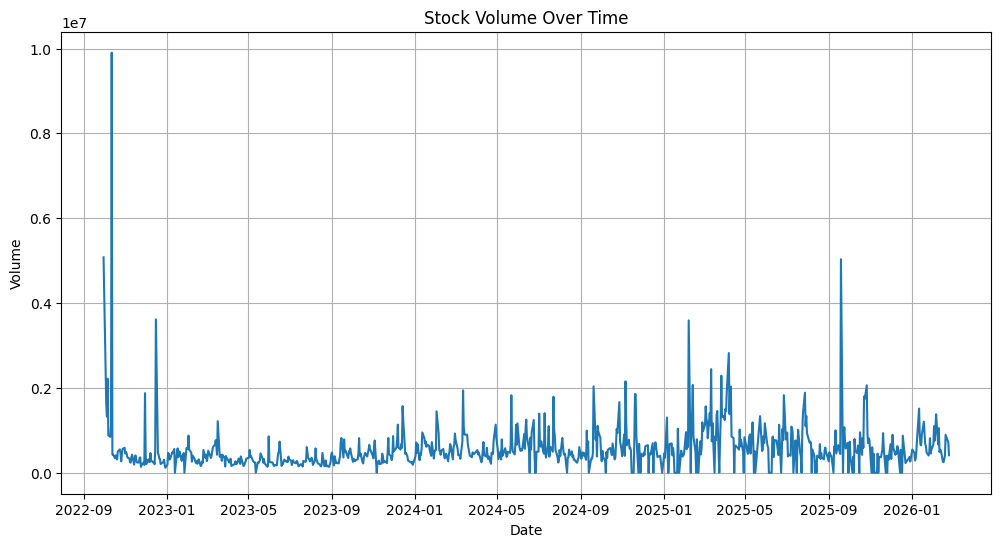

In [12]:
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='volume', data=df)
plt.title('Stock Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

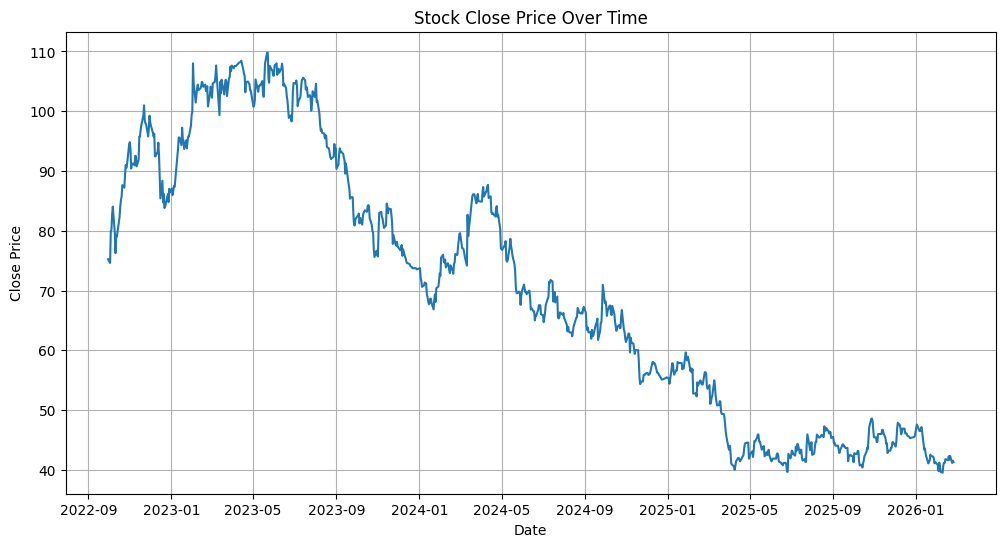

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='close', data=df)
plt.title('Stock Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

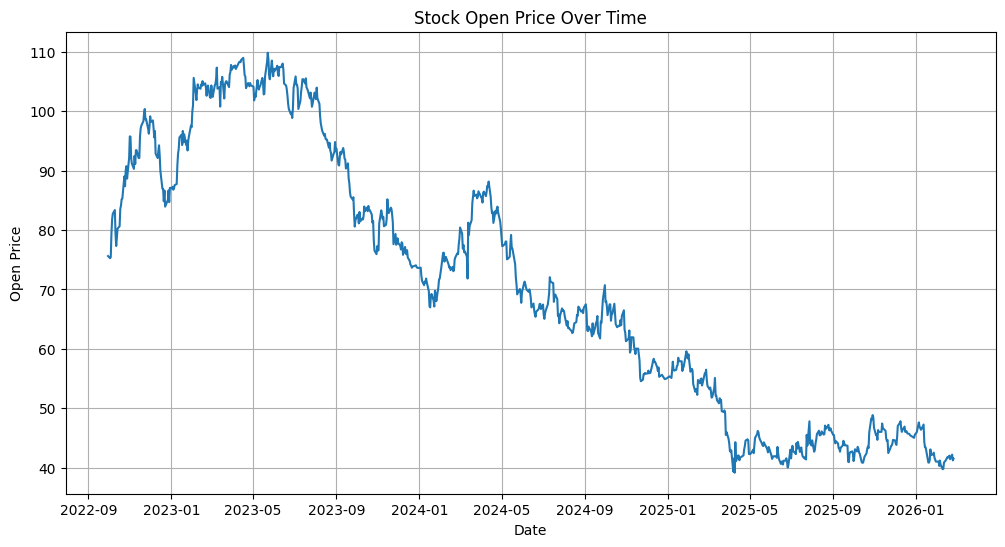

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='open', data=df)
plt.title('Stock Open Price Over Time')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.grid(True)
plt.show()

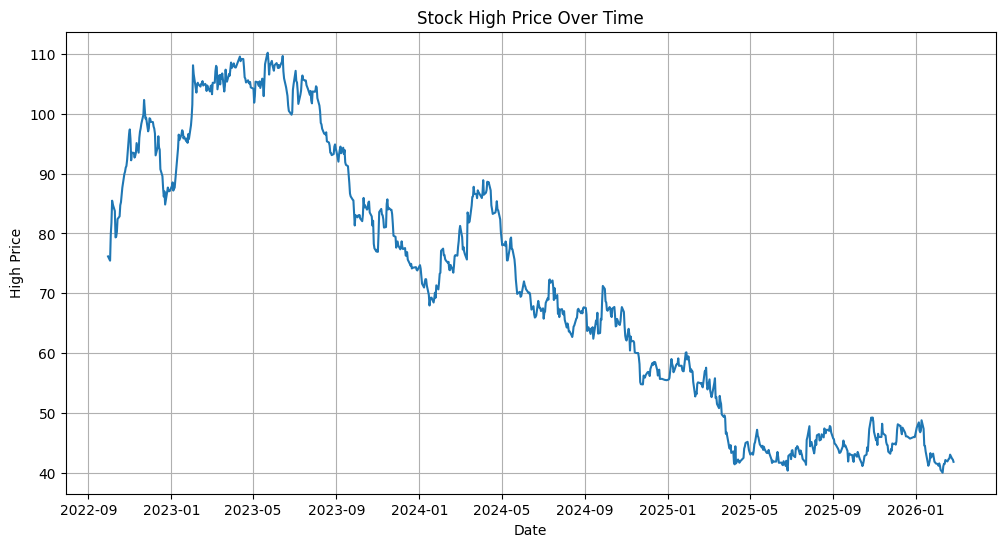

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='high', data=df)
plt.title('Stock High Price Over Time')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.grid(True)
plt.show()

In [16]:
df_knn = df.copy()

# Feature Engineering: Time-based features
df_knn['year'] = df_knn['date'].dt.year
df_knn['month'] = df_knn['date'].dt.month
df_knn['day'] = df_knn['date'].dt.day
df_knn['dayofweek'] = df_knn['date'].dt.dayofweek
df_knn['dayofyear'] = df_knn['date'].dt.dayofyear
df_knn['weekofyear'] = df_knn['date'].dt.isocalendar().week.astype(int)

# Feature Engineering: Lagged features
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_knn[f'{col}_lag1'] = df_knn[col].shift(1)

# Drop rows with NaN values resulting from lagged features
df_knn.dropna(inplace=True)

display(df_knn.head())

,date,open,high,low,close,volume,year,month,day,dayofweek,dayofyear,weekofyear,open_lag1,high_lag1,low_lag1,close_lag1,volume_lag1
1,2022-10-03,75.252548,75.453222,73.884320,74.614044,2403446,2022,10,3,0,276,40,75.617410,76.164700,75.252548,75.252548,5079137.0
2,2022-10-04,75.434974,79.795067,74.796470,79.795067,1599630,2022,10,4,1,277,40,75.252548,75.453222,73.884320,74.614044,2403446.0
3,2022-10-05,79.448447,81.765314,78.919397,80.196411,1321304,2022,10,5,2,278,40,75.434974,79.795067,74.796470,79.795067,1599630.0
4,2022-10-06,81.820036,85.468644,81.491661,82.750435,2217065,2022,10,6,3,279,40,79.448447,81.765314,78.919397,80.196411,1321304.0
5,2022-10-07,82.750444,84.848390,81.820045,84.027458,880174,2022,10,7,4,280,40,81.820036,85.468644,81.491661,82.750435,2217065.0


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
X = df_knn[['open_lag1', 'high_lag1', 'low_lag1', 'close_lag1', 'volume_lag1',
          'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear']]
y = df_knn['volume']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN Regressor model
knn_model = KNeighborsRegressor(n_neighbors=5) # Using 5 neighbors as a starting point
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn_model.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 246106.11
Mean Squared Error (MSE): 181454637876.15
Root Mean Squared Error (RMSE): 425974.93
R-squared (R2): 0.14


## Tune KNN Hyperparameters


In [18]:
r2_scores = []
n_neighbors_values = []

# Iterate through a range of n_neighbors values
for n in range(1, 21): # Testing n_neighbors from 1 to 20
    knn_model_tuned = KNeighborsRegressor(n_neighbors=n)
    knn_model_tuned.fit(X_train_scaled, y_train)
    y_pred_tuned = knn_model_tuned.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred_tuned)
    r2_scores.append(r2)
    n_neighbors_values.append(n)

# Find the n_neighbors with the highest R-squared score
best_n_index = np.argmax(r2_scores)
optimal_n_neighbors = n_neighbors_values[best_n_index]
highest_r2_score = r2_scores[best_n_index]

print(f"Optimal n_neighbors: {optimal_n_neighbors}")
print(f"Highest R-squared score: {highest_r2_score:.2f}")

Optimal n_neighbors: 6
Highest R-squared score: 0.18


In [19]:
df_knn['SMA_7_close'] = df_knn['close'].rolling(window=7).mean()
df_knn.dropna(inplace=True)

df_knn['EMA_14_close'] = df_knn['close'].ewm(span=14, adjust=False).mean()
df_knn.dropna(inplace=True)

df_knn['daily_return'] = df_knn['close'].pct_change() * 100
df_knn.dropna(inplace=True)

display(df_knn.head())

,date,open,high,low,close,volume,year,month,day,dayofweek,dayofyear,weekofyear,open_lag1,high_lag1,low_lag1,close_lag1,volume_lag1,SMA_7_close,EMA_14_close,daily_return
8,2022-10-12,77.314010,79.466689,76.839687,79.211281,9901667,2022,10,12,2,285,41,79.338999,79.338999,75.252554,76.255920,1123986.0,80.266779,76.649968,3.875582
9,2022-10-13,78.864680,80.269395,78.007255,79.010628,428569,2022,10,13,3,286,41,77.314010,79.466689,76.839687,79.211281,9901667.0,80.154716,76.964723,-0.253314
10,2022-10-14,80.251145,82.403817,78.974130,79.813309,429830,2022,10,14,4,287,41,78.864680,80.269395,78.007255,79.010628,428569.0,80.099988,77.344534,1.015915
11,2022-10-17,80.634250,82.859896,80.269387,82.367340,339747,2022,10,17,0,290,42,80.251145,82.403817,78.974130,79.813309,429830.0,80.045260,78.014242,3.200007
12,2022-10-18,83.553135,84.720689,82.677470,84.027458,409208,2022,10,18,1,291,42,80.634250,82.859896,80.269387,82.367340,339747.0,80.045260,78.816004,2.015505


In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define features (X) and target (y) with new features
X = df_knn[['open_lag1', 'high_lag1', 'low_lag1', 'close_lag1', 'volume_lag1',
          'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear',
          'SMA_7_close', 'EMA_14_close', 'daily_return']]
y = df_knn['volume']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- RandomForestRegressor ---
# Initialize and train the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions with RandomForestRegressor
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the RandomForestRegressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RandomForestRegressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")
print("\n")

# --- GradientBoostingRegressor ---
# Initialize and train the GradientBoostingRegressor model
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_scaled, y_train)

# Make predictions with GradientBoostingRegressor
y_pred_gbr = gbr_model.predict(X_test_scaled)

# Evaluate the GradientBoostingRegressor model
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("GradientBoostingRegressor Metrics:")
print(f"Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr:.2f}")
print(f"R-squared (R2): {r2_gbr:.2f}")

RandomForestRegressor Metrics:
Mean Absolute Error (MAE): 229860.69
Mean Squared Error (MSE): 219847384550.58
Root Mean Squared Error (RMSE): 468878.86
R-squared (R2): 0.25


GradientBoostingRegressor Metrics:
Mean Absolute Error (MAE): 223355.66
Mean Squared Error (MSE): 222140610650.34
Root Mean Squared Error (RMSE): 471317.95
R-squared (R2): 0.24


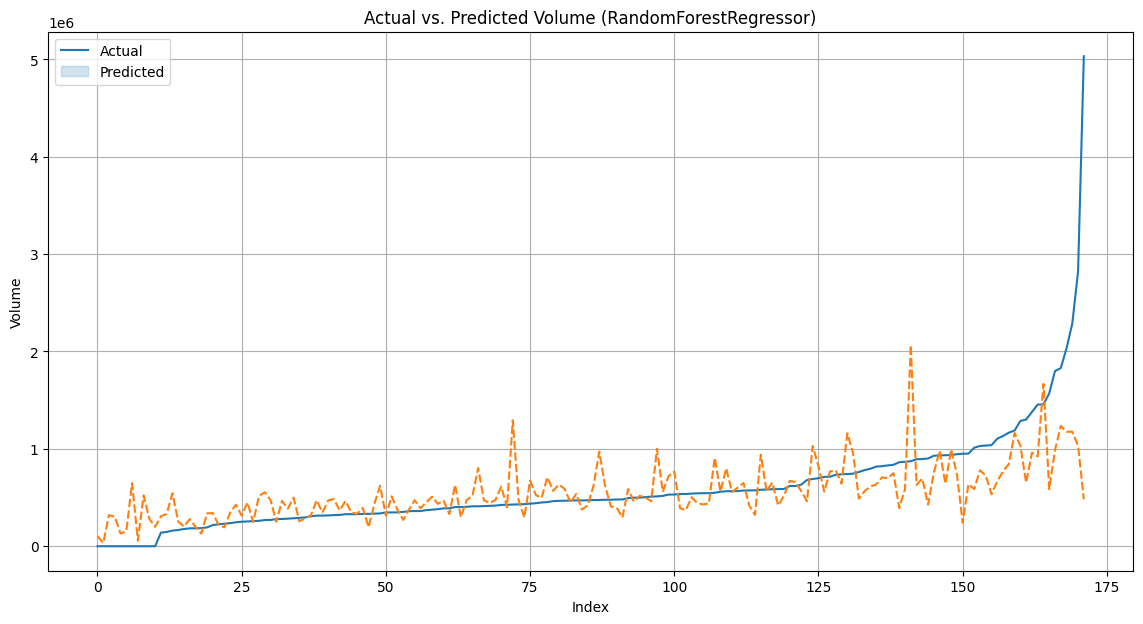

,Actual,Predicted
0,0,103291.40
1,0,32936.52
2,0,318962.52
3,0,303247.64
4,0,129804.80


In [21]:
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
results_df = results_df.sort_values(by='Actual').reset_index(drop=True)

plt.figure(figsize=(14, 7))
sns.lineplot(data=results_df[['Actual', 'Predicted']])
plt.title('Actual vs. Predicted Volume (RandomForestRegressor)')
plt.xlabel('Index')
plt.ylabel('Volume')
plt.legend(['Actual', 'Predicted'])
plt.grid(True)
plt.show()

display(results_df.head())

In [25]:
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 0.8],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

print("Updated parameter grid for RandomForestRegressor defined with reduced options.")

Updated parameter grid for RandomForestRegressor defined with reduced options.


In [26]:
from sklearn.model_selection import GridSearchCV

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV with the updated param_grid
grid_search_reduced = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='r2', cv=5, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_reduced.fit(X_train_scaled, y_train)

print("GridSearchCV training with reduced parameter grid complete.")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV training with reduced parameter grid complete.


In [27]:
print(f"Best parameters found: {grid_search_reduced.best_params_}")
print(f"Best R-squared score: {grid_search_reduced.best_score_:.2f}")

Best parameters found: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best R-squared score: 0.35


In [28]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', 0.8],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10, 15]
}

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Instantiate RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=20, scoring='r2', cv=5, n_jobs=-1, verbose=2,
                                   random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_scaled, y_train)

print("RandomizedSearchCV training complete.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
RandomizedSearchCV training complete.


In [29]:
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best R-squared score: {random_search.best_score_:.2f}")

Best parameters found: {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 30}
Best R-squared score: 0.35


In [30]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distributions for RandomizedSearchCV (same as before)
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', 0.8],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10, 15]
}

# Initialize RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Instantiate RandomizedSearchCV with cv=3
random_search_cv3 = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=20, scoring='r2', cv=3, n_jobs=-1, verbose=2,
                                   random_state=42)

# Fit RandomizedSearchCV to the training data
random_search_cv3.fit(X_train_scaled, y_train)

print("RandomizedSearchCV training with cv=3 complete.")

# Print the best parameters found
print(f"Best parameters found with cv=3: {random_search_cv3.best_params_}")

# Print the best R-squared score
print(f"Best R-squared score with cv=3: {random_search_cv3.best_score_:.2f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
RandomizedSearchCV training with cv=3 complete.
Best parameters found with cv=3: {'n_estimators': 300, 'min_samples_split': 15, 'max_features': 0.8, 'max_depth': 10}
Best R-squared score with cv=3: 0.32


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Retrieve the best estimator
best_rf_model = random_search_cv3.best_estimator_

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test_scaled)

# Evaluate the best model
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("Best RandomForestRegressor Metrics (after RandomizedSearchCV with cv=3):")
print(f"Mean Absolute Error (MAE): {mae_best_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_best_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_rf:.2f}")
print(f"R-squared (R2): {r2_best_rf:.2f}")

Best RandomForestRegressor Metrics (after RandomizedSearchCV with cv=3):
Mean Absolute Error (MAE): 219480.23
Mean Squared Error (MSE): 214603547329.23
Root Mean Squared Error (RMSE): 463253.22
R-squared (R2): 0.26
